# 05 焼きなまし法による多角形パッキングの最適化

## 理論まとめ

### アイデア
多角形BL法の解品質は、図形を配置する**順序**と各図形の**回転角**の組み合わせに大きく依存する。
順序と回転角の全探索は $n! \times |\Theta|^n$ 通りになり非現実的なので、
焼きなまし法で「良い順序 × 回転角の組み合わせ」を探索する。

### 矩形版との違い
| 要素 | 矩形版 | 多角形版（今回） |
|------|--------|----------------|
| 状態 | 配置順序のみ | 配置順序 + 各図形の回転角 |
| 近傍操作 | swap / insert | swap / insert / **rotate**（追加） |
| 評価関数 | `find_bl_point`（軽量） | `find_bl_point_polygon`（NFP・IFR計算を含む） |
| キャッシュ | なし | NFP・IFRを事前計算してSA全体で再利用 |

### 焼きなまし法の構成要素
| 要素 | 今回の設定 |
|------|----------|
| 状態 | 配置順序（インデックスの順列）+ 各図形の回転角リスト |
| 近傍操作 | `swap`: 順序の2要素スワップ / `insert`: 1要素を別位置に挿入 / `rotate`: 1図形の回転角を変更 |
| 目的関数 | 使用した高さ（最小化） |
| 受理確率 | $\exp(-\Delta / T)$（悪化解も確率的に受理） |
| 冷却スケジュール | 指数冷却 $T \leftarrow T \times \alpha$ |

### `rotate` 近傍について
多角形版で新たに追加した近傍操作。
ランダムに1つの図形を選び、現在の回転角以外の角度にランダムに変更する。
順序操作（swap / insert）と組み合わせる `mixed` モードが最も探索の多様性を確保できる。

### 計算コストについて
多角形BL法は評価1回あたりのコストが矩形版より大幅に高い。
NFP・IFRキャッシュを事前計算してSA全体で再利用することで計算量を抑えているが、
図形数が多い場合は1回の実行に数分〜数十分かかることがある。
デモ用途では図形数5〜10、反復数500〜2000程度が現実的な設定となる。

In [1]:
import sys
sys.path.insert(0, '..')

from algorithms.polygon_bl                   import bl_method_polygon
from algorithms.polygon_simulated_annealing  import simulated_annealing_polygon, SAResult
from algorithms.nfp_polygon                  import make_polygon
from utils.visualizer                        import plot_polygon_packing
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time

In [2]:
# 充填率の計算
def fill_rate(polygons, positions, bin_w):
    used_h = max(pos[1] + poly.bounds[3] for poly, pos in zip(polygons, positions))
    return sum(p.area for p in polygons) / (bin_w * used_h) * 100

## 1. 基本動作の確認

縦横比が異なる図形セットで、多角形BL法（回転あり）と焼きなまし法の結果を比較する。

In [3]:
# 問題設定：縦横比が異なる矩形（回転の効果が出やすい）
vertices_list = [
    [(0,0),(40,0),(40,10),(0,10)],
    [(0,0),(5,0),(5,30),(0,30)],
    [(0,0),(30,0),(30,5),(0,5)],
    [(0,0),(20,0),(20,15),(0,15)],
    [(0,0),(8,0),(8,25),(0,25)],
]
bin_w = 50.0
orientations = [0, 90, 180, 270]

# ベースライン：多角形BL法（回転あり）
t0 = time.perf_counter()
pos_bl, thetas_bl, polys_bl = bl_method_polygon(
    vertices_list, bin_w, orientations=orientations, sort_key='area'
)
t_bl = time.perf_counter() - t0
fill_bl = fill_rate(polys_bl, pos_bl, bin_w)
print(f'BL法（回転あり）: 充填率={fill_bl:.1f}%  実行時間={t_bl:.3f}s')

# 焼きなまし法
t0 = time.perf_counter()
result = simulated_annealing_polygon(
    vertices_list, bin_w,
    orientations=orientations,
    t_start=5.0, t_end=0.01, cooling=0.995,
    max_iter=2000, neighbor='mixed', seed=42, log_interval=100
)
t_sa = time.perf_counter() - t0
fill_sa = fill_rate(result.best_polys, result.best_positions, bin_w)
print(f'焼きなまし法:     充填率={fill_sa:.1f}%  (+{fill_sa-fill_bl:.1f}%)  実行時間={t_sa:.3f}s')

BL法（回転あり）: 充填率=60.0%  実行時間=0.272s
焼きなまし法:     充填率=85.7%  (+25.7%)  実行時間=42.124s


## 2. 配置結果の可視化

BL法（回転あり）と焼きなまし法の配置結果を並べて比較する。

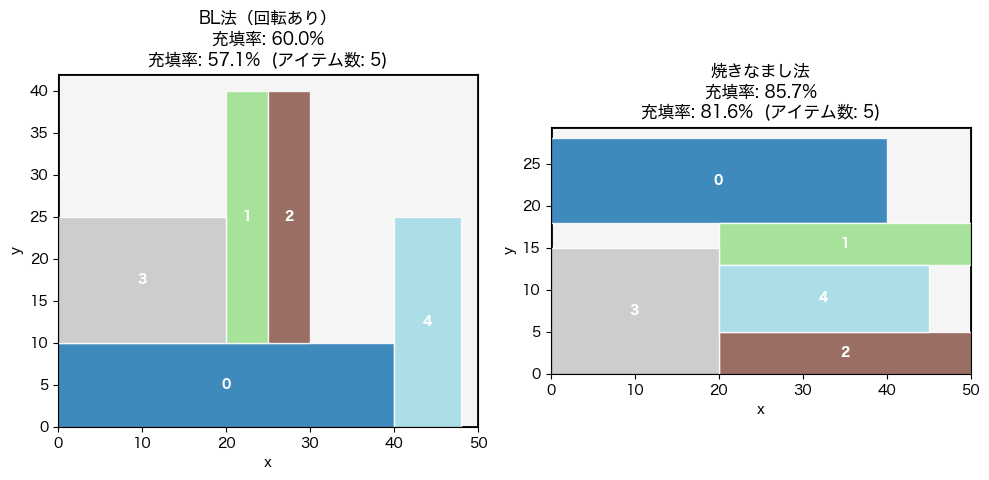

--- 最良解の回転角 ---
BL法:       [0, 0, 90, 0, 0]
焼きなまし法: [180, 90, 180, 0, 270]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_polygon_packing(
    polys_bl, pos_bl, bin_w,
    title=f'BL法（回転あり）\n充填率: {fill_bl:.1f}%',
    ax=axes[0], show=False,
)
plot_polygon_packing(
    result.best_polys, result.best_positions, bin_w,
    title=f'焼きなまし法\n充填率: {fill_sa:.1f}%',
    ax=axes[1], show=False,
)

plt.tight_layout()
plt.show()

# 各図形の回転角を表示
print('--- 最良解の回転角 ---')
print(f'BL法:       {thetas_bl}')
print(f'焼きなまし法: {result.best_thetas}')

## 3. 収束曲線の可視化

反復数に対する「使用した高さ」の推移を確認する。
温度が下がるにつれて解が安定していく様子が観察できる。

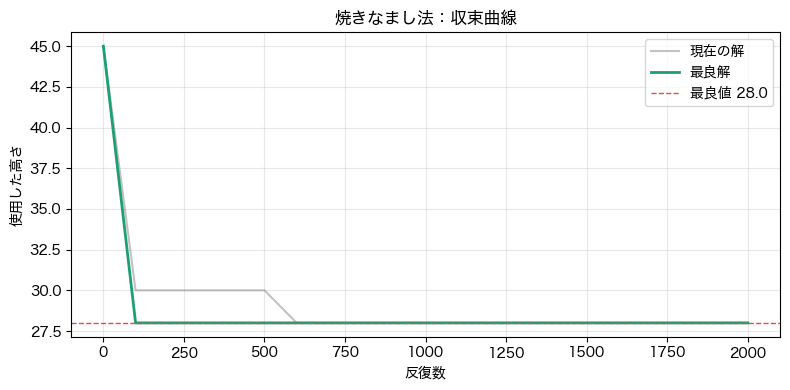

In [5]:
iters        = [h[0] for h in result.history]
heights_cur  = [h[1] for h in result.history]
heights_best = [h[2] for h in result.history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iters, heights_cur,  alpha=0.5, color='#888780', label='現在の解')
ax.plot(iters, heights_best, color='#1D9E75', lw=2,      label='最良解')
ax.axhline(y=result.best_height, color='#E24B4A', lw=1, ls='--',
           label=f'最良値 {result.best_height:.1f}')
ax.set_xlabel('反復数')
ax.set_ylabel('使用した高さ')
ax.set_title('焼きなまし法：収束曲線')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 近傍操作の比較

`swap` / `insert` / `rotate` / `mixed` の4種類の近傍操作を同じ問題・同じシードで比較する。

- `swap`   : 順序の変更のみ → 回転角は初期値（0度）から動かない
- `rotate` : 回転角の変更のみ → 順序は初期値（面積降順）から動かない
- `mixed`  : 両方を組み合わせることで最も広い探索空間をカバーできる

In [6]:
neighbor_types = ['swap', 'insert', 'rotate', 'mixed']
results_nb = {}

for nb in neighbor_types:
    r = simulated_annealing_polygon(
        vertices_list, bin_w,
        orientations=orientations,
        t_start=5.0, t_end=0.01, cooling=0.995,
        max_iter=2000, neighbor=nb, seed=42, log_interval=100
    )
    f = fill_rate(r.best_polys, r.best_positions, bin_w)
    results_nb[nb] = {'result': r, 'fill': f}
    print(f'{nb:8s}: 充填率={f:.1f}%  実行時間={r.elapsed:.3f}s')

print(f'\nBL法ベースライン: 充填率={fill_bl:.1f}%')

swap    : 充填率=68.6%  実行時間=30.948s
insert  : 充填率=68.6%  実行時間=36.599s
rotate  : 充填率=85.7%  実行時間=59.995s
mixed   : 充填率=85.7%  実行時間=57.231s

BL法ベースライン: 充填率=60.0%


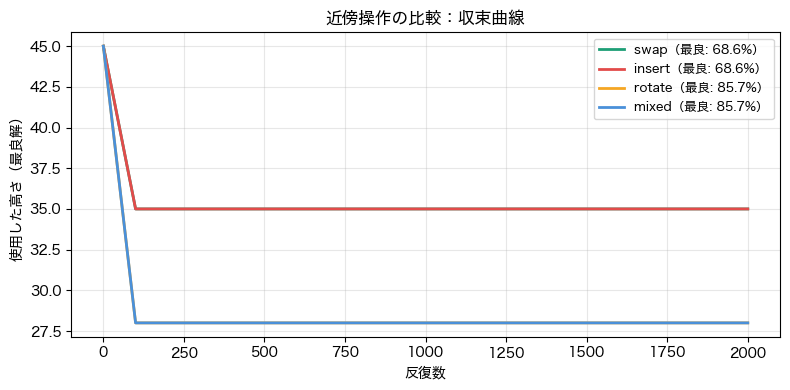

In [7]:
# 収束曲線の比較
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1D9E75', '#E24B4A', '#F5A623', '#4A90D9']

for (nb, res), color in zip(results_nb.items(), colors):
    iters_nb = [h[0] for h in res['result'].history]
    best_nb  = [h[2] for h in res['result'].history]
    ax.plot(iters_nb, best_nb, color=color, lw=2,
            label=f"{nb}（最良: {res['fill']:.1f}%）")

ax.set_xlabel('反復数')
ax.set_ylabel('使用した高さ（最良解）')
ax.set_title('近傍操作の比較：収束曲線')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 計算時間の考察

多角形SAの計算時間は矩形版と大きく異なる。
評価関数1回あたりのコストを測定し、図形数・反復数との関係を確認する。

In [9]:
from algorithms.polygon_simulated_annealing import evaluate
from algorithms.nfp_polygon import make_polygon, build_nfp_cache, build_ifr_cache, rotate_polygon

# evaluate() 1回あたりの計算時間を測定
polygons = [make_polygon(v) for v in vertices_list]
nfp_cache = build_nfp_cache(polygons, orientations)
ifr_cache = build_ifr_cache(polygons, orientations, bin_w)

n = len(polygons)
order  = list(range(n))
thetas = [0] * n

n_trials = 100
t0 = time.perf_counter()
for _ in range(n_trials):
    evaluate(order, thetas, polygons, nfp_cache, ifr_cache)
t_eval = (time.perf_counter() - t0) / n_trials

print(f'evaluate() 1回あたりの平均時間: {t_eval*1000:.2f} ms')
print()
print('反復数と予想実行時間の目安（キャッシュ構築時間を除く）:')
for itr in [500, 1000, 2000, 5000, 10000]:
    print(f'  {itr:6d} 反復: 約 {t_eval * itr:.1f}s')

evaluate() 1回あたりの平均時間: 17.58 ms

反復数と予想実行時間の目安（キャッシュ構築時間を除く）:
     500 反復: 約 8.8s
    1000 反復: 約 17.6s
    2000 反復: 約 35.2s
    5000 反復: 約 87.9s
   10000 反復: 約 175.8s


In [10]:
# キャッシュ構築時間の測定
print('NFP/IFRキャッシュ構築時間（図形数・回転角数別）:')
for n_shapes in [5, 8, 10]:
    vlist_test = vertices_list[:n_shapes] if n_shapes <= len(vertices_list) else vertices_list * (n_shapes // len(vertices_list) + 1)
    vlist_test = vlist_test[:n_shapes]
    polys_test = [make_polygon(v) for v in vlist_test]
    t0 = time.perf_counter()
    build_nfp_cache(polys_test, orientations)
    build_ifr_cache(polys_test, orientations, bin_w)
    t_cache = time.perf_counter() - t0
    print(f'  n={n_shapes:2d}, 回転角{len(orientations)}種: {t_cache:.3f}s')

NFP/IFRキャッシュ構築時間（図形数・回転角数別）:
  n= 5, 回転角4種: 0.276s
  n= 8, 回転角4種: 0.550s
  n=10, 回転角4種: 0.954s


## まとめ・次のステップ

### 確認できたこと
- 焼きなまし法による配置順序 × 回転角の最適化が正しく動作することを確認した
- 多角形BL法（回転あり）をベースラインとして、充填率の改善を達成した
- `mixed` 近傍（swap + insert + rotate）が最も広い探索空間をカバーできる
- 収束曲線から、温度降下に伴って解が安定していく様子が確認できた

### 実装のポイント
- NFP・IFRキャッシュをSA開始時に1度だけ計算し全反復で再利用することで計算量を削減
- `rotate_one` 近傍を追加することで、順序操作だけでは届かない解空間を探索できる
- 評価関数の構成は矩形版と同じ設計（`find_bl_point_*` を直接呼び出す形）で可読性を維持

### 計算コストの課題
- 評価1回あたりのコストが矩形版より大幅に高いため、図形数が増えると実行時間が急増する
- 実用上は図形数5〜10、反復数500〜2000程度が現実的な設定
- より大規模な問題への対応には、今堀ら(2007)のILSQN（SEPARATE + SWAPTWOPOLYGONS）のような
  非線形最適化ベースの手法が必要になる

### 次のステップ
- Streamlit デモへの統合・Streamlit Cloud への再デプロイ
- Qiita 記事の執筆（多角形パッキング × 焼きなまし法）